In [16]:
"""
This notebook conducts exploratory data analysis (EDA) for the Histopathologic Cancer Detection Kaggle competition.
The dataset consists of labeled 96x96 pixel image patches derived from larger pathology scans. Each image is classified as either containing metastatic tissue (label 1) or not (label 0).

The primary goal of this notebook is to understand the structure and distribution of the data. We begin by loading the image and label data, assessing class imbalance, and examining a few samples of the tissue images. This will help shape our modeling decisions later on.
We also verify image dimensions and format consistency. All findings will inform how we construct a suitable model architecture and preprocessing pipeline in subsequent stages.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from PIL import Image

df = pd.read_csv("../data/train_labels.csv")
print("Shape:", df.shape)
df.head()

Shape: (220025, 2)


,id,label
0,f38a6374c348f90b587e046aac6079959adf3835,0
1,c18f2d887b7ae4f6742ee445113fa1aef383ed77,1
2,755db6279dae599ebb4d39a9123cce439965282d,0
3,bc3f0c64fb968ff4a8bd33af6971ecae77c75e08,0
4,068aba587a4950175d04c680d38943fd488d6a9d,0


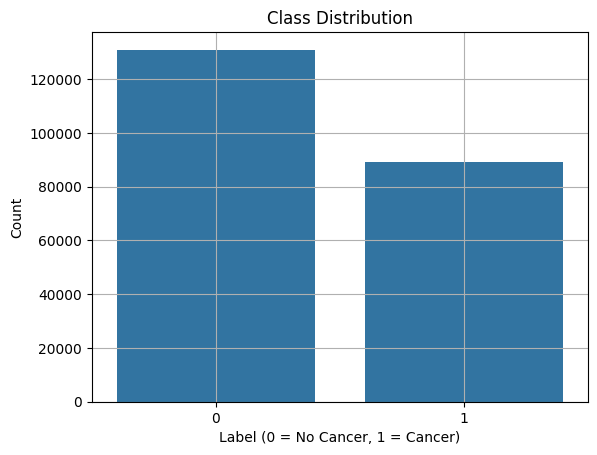

In [17]:
sns.countplot(data=df, x="label")
plt.title("Class Distribution")
plt.xlabel("Label (0 = No Cancer, 1 = Cancer)")
plt.ylabel("Count")
plt.grid(True)
plt.show()

In [20]:
sample = Image.open("../data/train/" + df.iloc[0]['id'] + ".tif")
print(sample.size, sample.mode)  # Should be (96, 96) and "RGB"

(96, 96) RGB


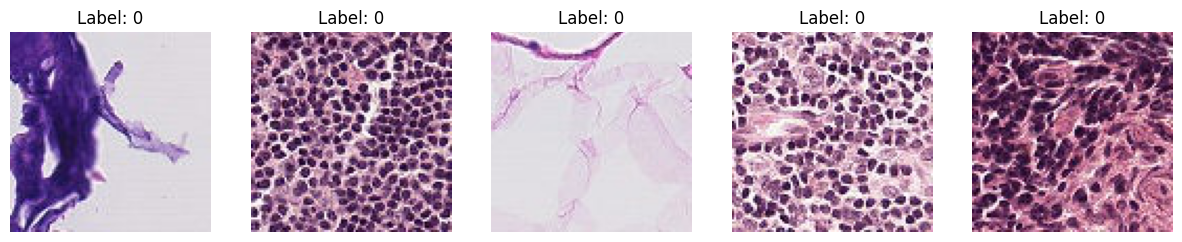

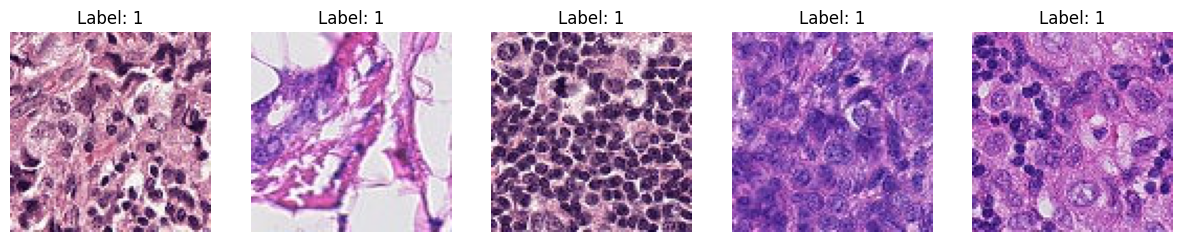

In [22]:
from PIL import Image
import matplotlib.pyplot as plt

def show_samples(df, label, n=5):
    samples = df[df['label'] == label].sample(n)['id']
    fig, axs = plt.subplots(1, n, figsize=(15, 3))
    for i, img_id in enumerate(samples):
        img = Image.open(f"../data/train/{img_id}.tif")
        axs[i].imshow(img)
        axs[i].axis('off')
        axs[i].set_title(f"Label: {label}")
    plt.show()

show_samples(df, label=0)
show_samples(df, label=1)

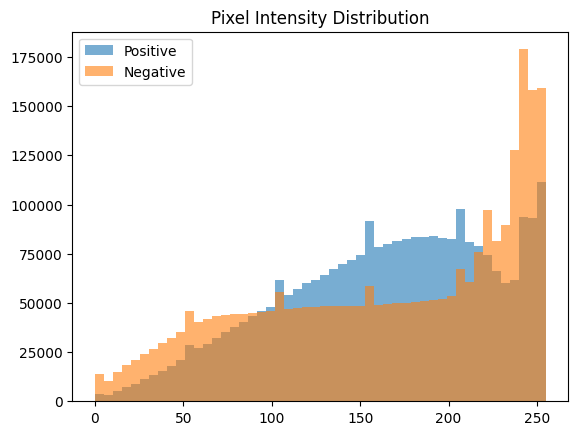

In [24]:
import numpy as np

def pixel_histogram(img_ids):
    pixels = []
    for img_id in img_ids:
        img = np.array(Image.open(f"../data/train/{img_id}.tif"))
        pixels.append(img.flatten())
    return np.concatenate(pixels)

pos_ids = train_labels[df['label'] == 1]['id'].sample(100)
neg_ids = train_labels[df['label'] == 0]['id'].sample(100)

plt.hist(pixel_histogram(pos_ids), bins=50, alpha=0.6, label='Positive')
plt.hist(pixel_histogram(neg_ids), bins=50, alpha=0.6, label='Negative')
plt.legend()
plt.title("Pixel Intensity Distribution")
plt.show()